In [1]:
# Bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, HTML
import warnings
warnings.filterwarnings('ignore')


# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau

# KerasNLP pour BERT
import keras_nlp

# Sklearn pour métriques
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Keggle hub pour dataset
import kagglehub

import re
import os

import pickle

# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU")
except Exception as e:
    print(f"Configuration GPU: {e}")

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"\n📦 TensorFlow version: {tf.__version__}")
print(f"📦 Keras version: {keras.__version__}")
print(f"📦 KerasNLP version: {keras_nlp.__version__}")

2026-04-14 08:46:14.713886: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 08:46:15.202399: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 08:46:17.122035: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 TensorFlow version: 2.20.0
📦 Keras version: 3.13.2
📦 KerasNLP version: 0.26.0


## 2. Récupération des données



In [2]:
print("Récupération des données...")
# Récupérer les données
path = kagglehub.dataset_download("haideradnan77/mental-health-condition-classification")

for f in os.listdir(path):
    df = pd.read_csv(os.path.join(path, f))

print(".. OK")

print("Nombre d'entrées : ", df.shape[0])

df.head()



Récupération des données...
.. OK
Nombre d'entrées :  103488


,text,status
0,"""My mind is a never-ending cycle of worry, and...",anxiety
1,Despite the sun shining and birds singing outs...,bipolar
2,"I'm drowning in responsibilities, each one dem...",stress
3,"""My emotions shift like the wind, leaving me u...",personality disorder
4,"I'm trapped in a whirlwind of thoughts, unable...",anxiety


## 3. Analyse des données

Nous avons 7 classes:
	 anxiety 17620
	 bipolar 13708
	 depression 15901
	 normal 16068
	 personality disorder 13915
	 stress 15230
	 suicidal 11046


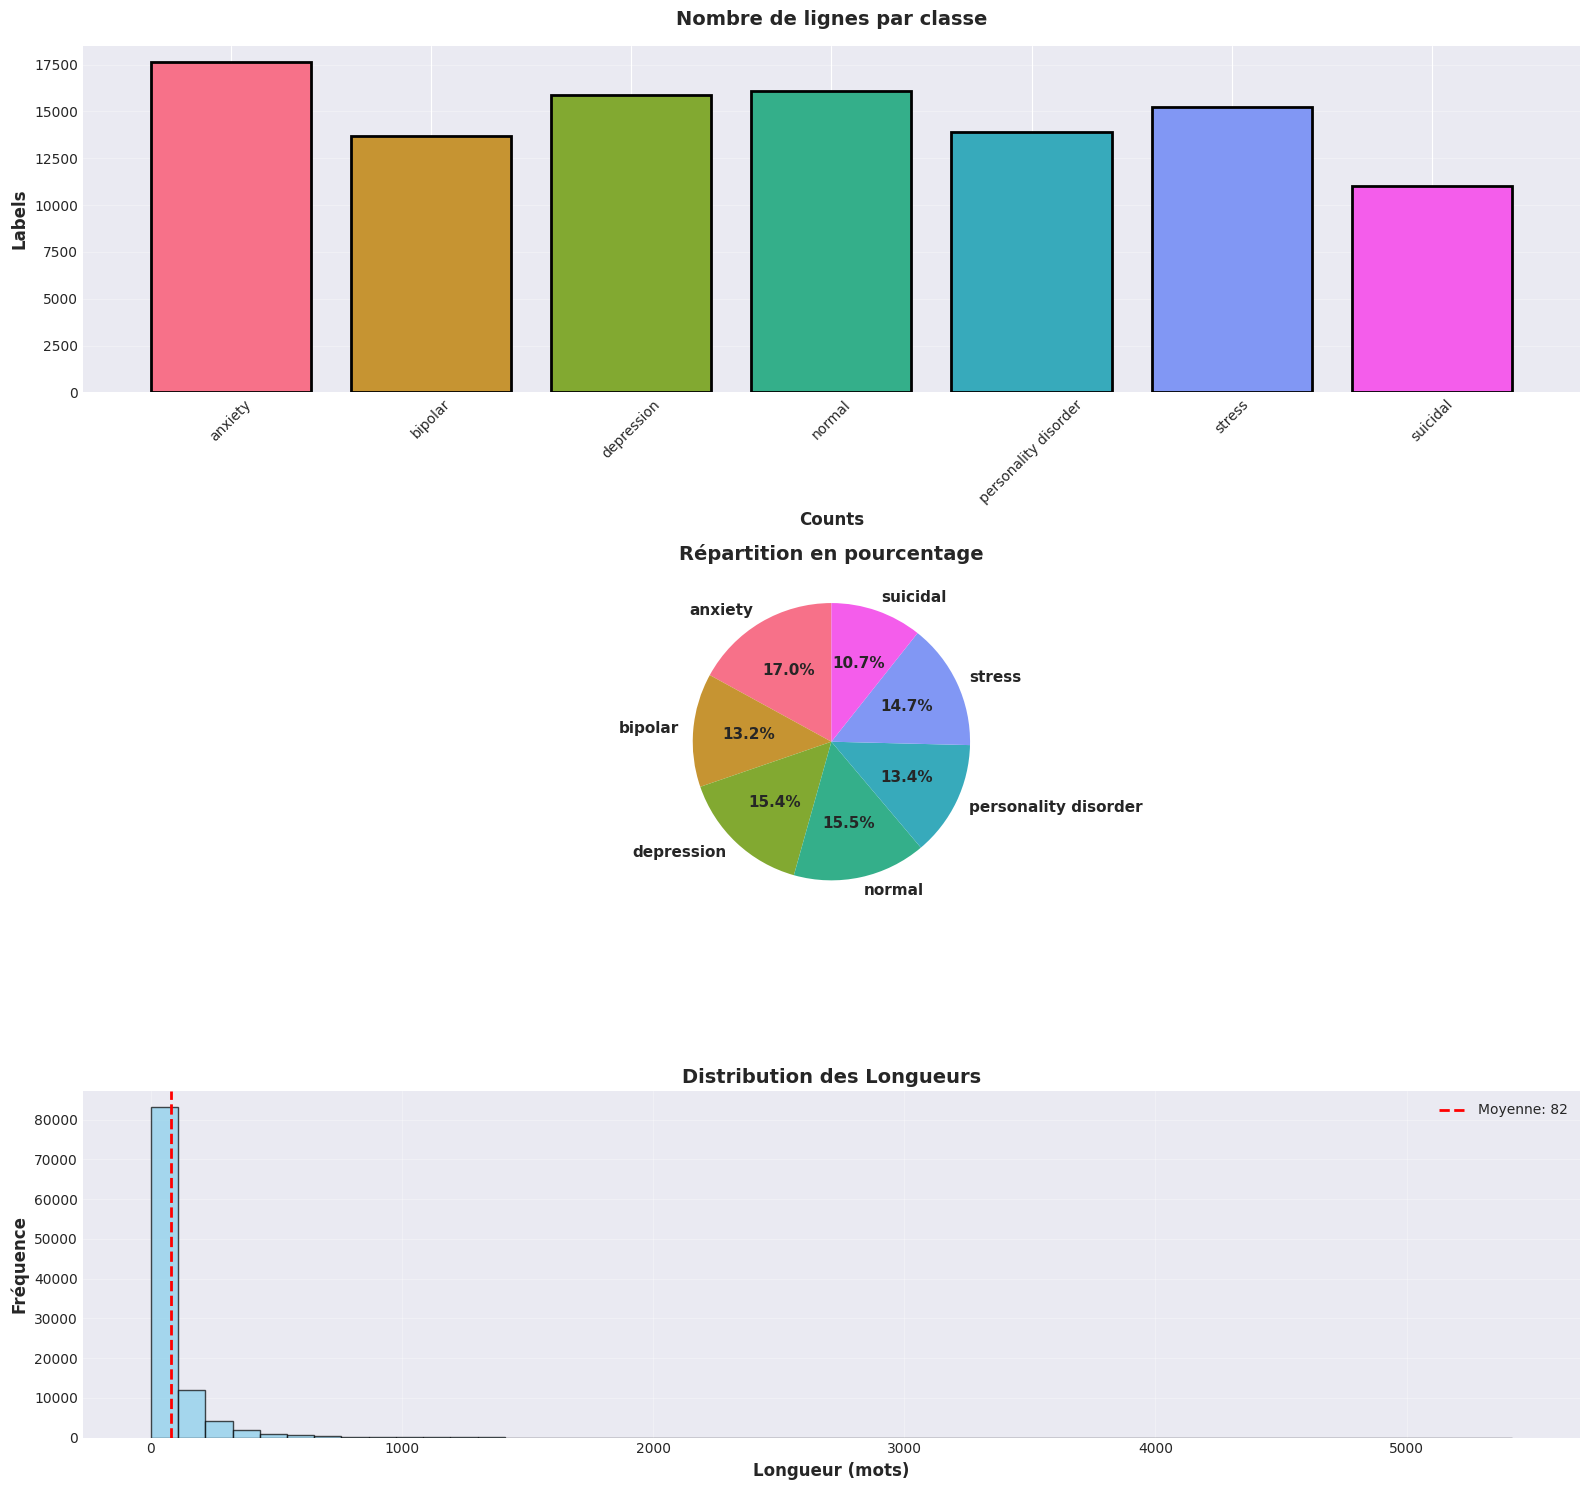

In [3]:
# analyse des données

statuses = df.groupby("status")

CLASSES_COUNT = len(statuses)
print(f"Nous avons {CLASSES_COUNT} classes:")

for name, group in statuses:
    print("\t", name, len(group))


chart_values = [len(group) for _, group in statuses]
chart_labels = [name for name, _ in statuses]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 15))
colors = sns.color_palette("husl", len(statuses))

bars = ax1.bar(range(len(statuses)), chart_values, color=colors, edgecolor='black', linewidth=2)
ax1.set_xlabel('Counts', fontsize=12, fontweight='bold')
ax1.set_ylabel('Labels', fontsize=12, fontweight='bold')
ax1.set_title(f'Nombre de lignes par classe', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(range(len(statuses)))
ax1.set_xticklabels(chart_labels)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

ax2.pie(chart_values, labels=chart_labels, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Répartition en pourcentage', fontsize=14, fontweight='bold')

# Distribution des longueurs
train_lengths = [len(row["text"].split()) for _, row in df.iterrows()]

ax3.hist(train_lengths, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax3.axvline(np.mean(train_lengths), color='red', linestyle='--', linewidth=2, 
            label=f'Moyenne: {np.mean(train_lengths):.0f}')
ax3.set_xlabel('Longueur (mots)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Fréquence', fontsize=12, fontweight='bold')
ax3.set_title('Distribution des Longueurs', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4.1 Nettoyage de données

In [4]:
df_copy = df.copy()
df_copy = df_copy[df_copy["text"].str.split().str.len() <= 1000]
#df_copy.loc[df_copy["status"].str.contains(r"\bsuicidal\b", case=False, na=False), "status"] = "depression"


Nous avons 7 classes:
	 anxiety 17605
	 bipolar 13700
	 depression 15752
	 normal 16068
	 personality disorder 13910
	 stress 15228
	 suicidal 10975


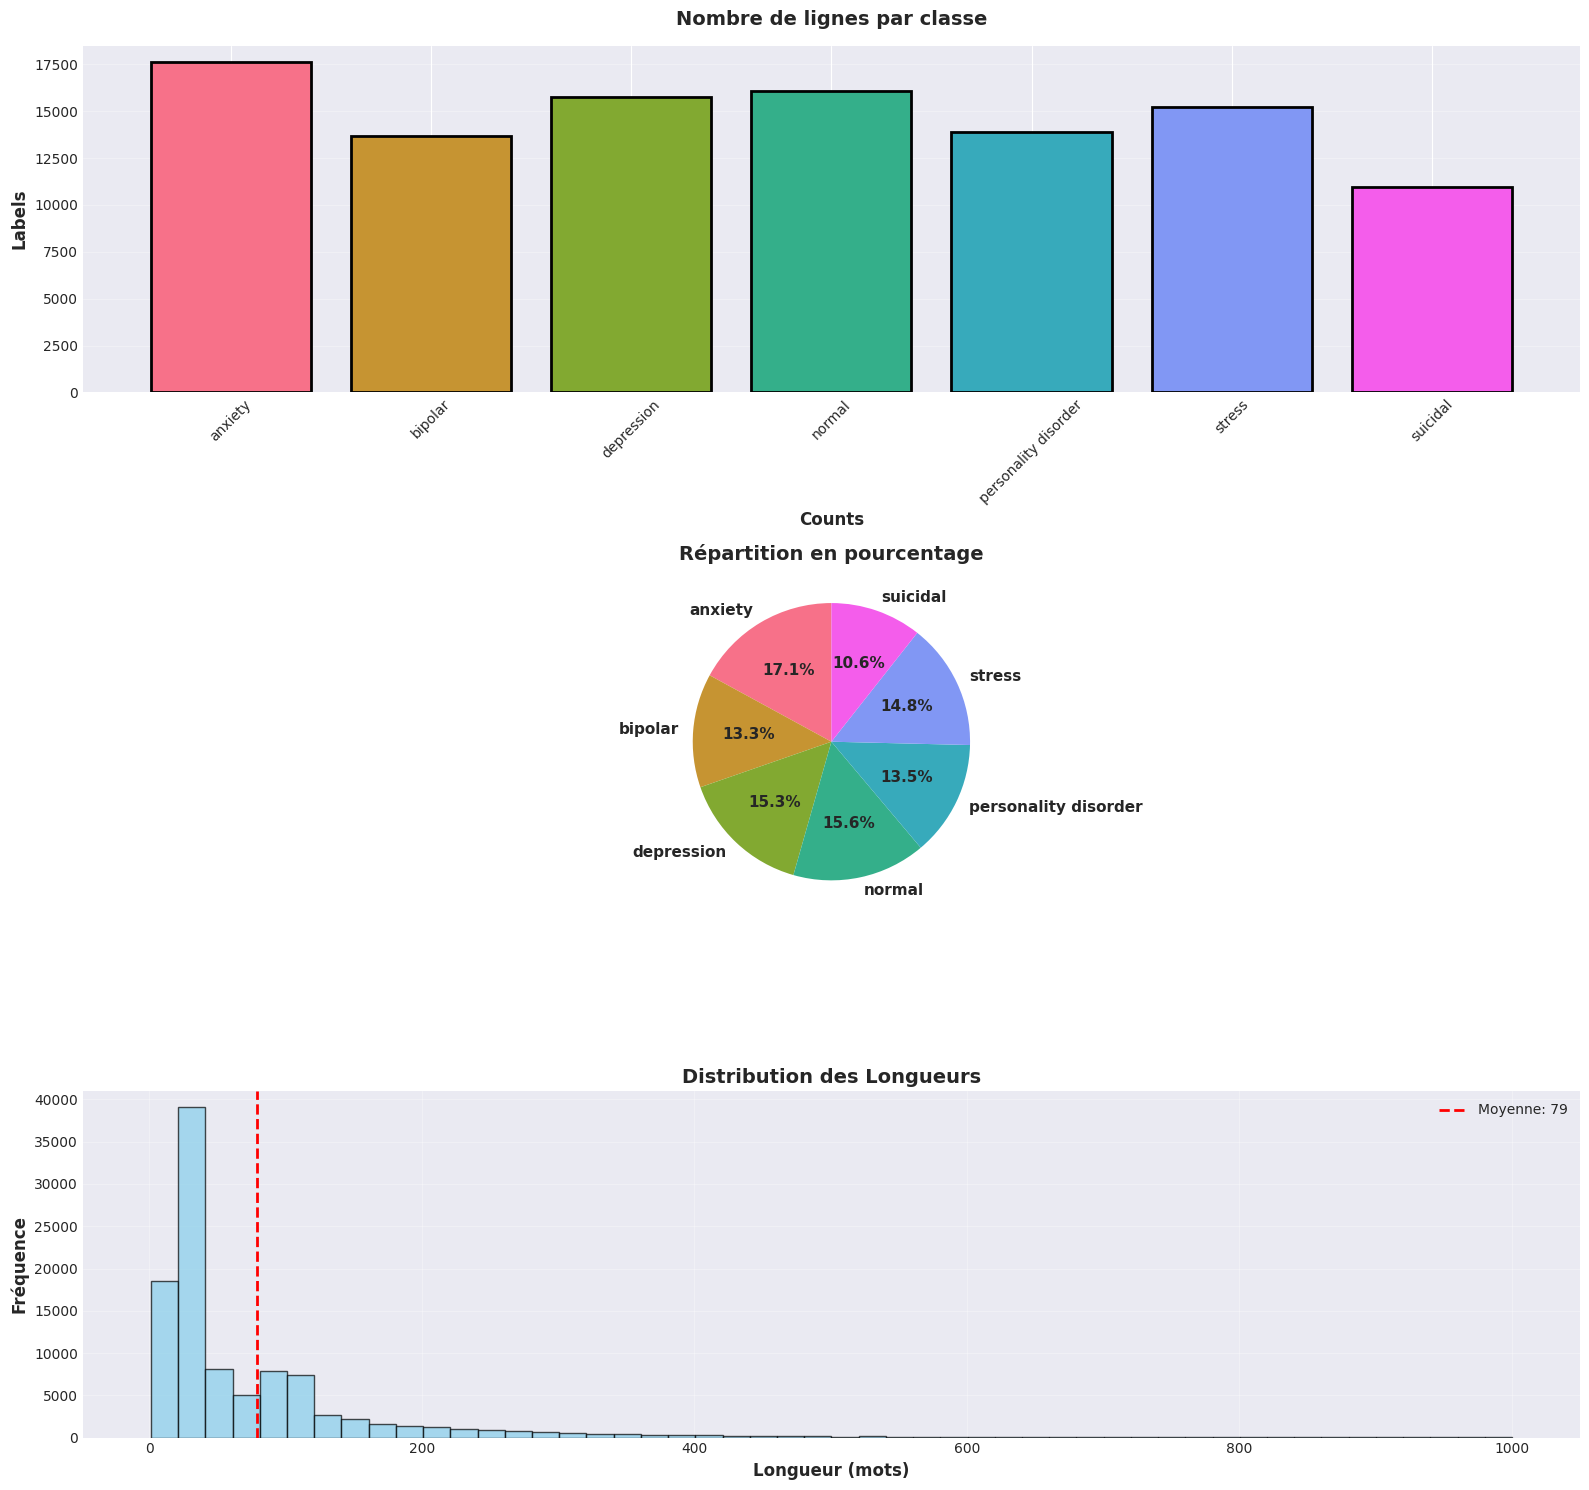

In [5]:
statuses = df_copy.groupby("status")

CLASSES_COUNT = len(statuses)
print(f"Nous avons {CLASSES_COUNT} classes:")

for name, group in statuses:
    print("\t", name, len(group))


chart_values = [len(group) for _, group in statuses]
chart_labels = [name for name, _ in statuses]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 15))
colors = sns.color_palette("husl", len(statuses))

bars = ax1.bar(range(len(statuses)), chart_values, color=colors, edgecolor='black', linewidth=2)
ax1.set_xlabel('Counts', fontsize=12, fontweight='bold')
ax1.set_ylabel('Labels', fontsize=12, fontweight='bold')
ax1.set_title(f'Nombre de lignes par classe', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(range(len(statuses)))
ax1.set_xticklabels(chart_labels)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

ax2.pie(chart_values, labels=chart_labels, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Répartition en pourcentage', fontsize=14, fontweight='bold')

# Distribution des longueurs
train_lengths = [len(row["text"].split()) for _, row in df_copy.iterrows()]

ax3.hist(train_lengths, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax3.axvline(np.mean(train_lengths), color='red', linestyle='--', linewidth=2, 
            label=f'Moyenne: {np.mean(train_lengths):.0f}')
ax3.set_xlabel('Longueur (mots)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Fréquence', fontsize=12, fontweight='bold')
ax3.set_title('Distribution des Longueurs', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Division des données

In [6]:
X_train_all, X_test_raw, y_train_all, y_test_raw = train_test_split(df_copy["text"], df_copy["status"], test_size=0.2, random_state=SEED)

# Créer un validation set
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_all, y_train_all, test_size=0.25, random_state=SEED, stratify=y_train_all
)

print(f"✅ Préparation terminée !")
print(f"\n📊 Répartition finale:")
print(f"   Train: {len(X_train_raw):,} elements")
print(f"   Validation: {len(X_val_raw):,} elements")
print(f"   Test: {len(X_test_raw):,} elements")


✅ Préparation terminée !

📊 Répartition finale:
   Train: 61,942 elements
   Validation: 20,648 elements
   Test: 20,648 elements


## 5. Nettoyage des données

In [7]:
# nettoyage et normalisation du texte
def clean_text(text: str):
    # Supprimer les sauts de ligne, remplacement de doubles quotes, convertir en minuscules
    text = text.replace("\n", " ").replace("\"", " ").lower()
    # Ajouter des espaces autour de la ponctuation
    text = re.sub(r"([.,!?'])", r" \1 ", text)
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

X_train = X_train_raw.transform(clean_text)
X_val = X_val_raw.transform(clean_text)
X_test = X_test_raw.transform(clean_text)

train_lengths = [len(elem.split(" ")) for elem in X_train]
print(f'Mean: {np.mean(train_lengths):.0f}, Std: {np.std(train_lengths):.0f}')

print("Nettoyage terminé")


Mean: 90, Std: 119
Nettoyage terminé


In [8]:
# Configuration
MAX_WORDS = 10000
MAX_LEN = 250

# tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<UNK>')

tokenizer.fit_on_texts(X_train)
VOCAB_SIZE = len(tokenizer.word_index) + 1  # +1 pour le padding

print(f"\nVocabulaire: {VOCAB_SIZE} tokens")

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# padding
tokenized_X_train = tokenizer.texts_to_sequences(X_train)
tokenized_X_val = tokenizer.texts_to_sequences(X_val)
tokenized_X_test = tokenizer.texts_to_sequences(X_test)

# padding
pad_X_train = pad_sequences(tokenized_X_train, maxlen=MAX_LEN, padding='post')
pad_X_val = pad_sequences(tokenized_X_val, maxlen=MAX_LEN, padding='post')
pad_X_test = pad_sequences(tokenized_X_test, maxlen=MAX_LEN, padding='post')

max_sequence_length = max([len(phrase) for phrase in tokenized_X_train])

# labels
y_labels = chart_labels

y_train_array = y_train_raw.transform(lambda x: y_labels.index(x))
y_train = tf.keras.utils.to_categorical(y_train_array, num_classes=len(y_labels))

y_val_array = y_val_raw.transform(lambda x: y_labels.index(x))
y_val = tf.keras.utils.to_categorical(y_val_array, num_classes=len(y_labels))

y_test_array = y_test_raw.transform(lambda x: y_labels.index(x))
y_test = tf.keras.utils.to_categorical(y_test_array, num_classes=len(y_labels))

print(f"\n Dimensions des données :")
print(f"  X (input)  : {pad_X_train.shape} - (nombre_sequences, longueur_sequence)")
print(f"  y (output) : {y_train.shape} - (nombre_sequences, classes)")
print(f"\n  Longueur maximale de séquence : {max_sequence_length}")



Vocabulaire: 49062 tokens

 Dimensions des données :
  X (input)  : (61942, 250) - (nombre_sequences, longueur_sequence)
  y (output) : (61942, 7) - (nombre_sequences, classes)

  Longueur maximale de séquence : 1022


In [9]:
class LivePlotCallback(Callback):
    """
    Callback pour visualiser les métriques d'entraînement en temps réel.
    """
    def on_train_begin(self, logs=None):
        self.epochs = []
        self.loss = []
        self.val_loss = []
        self.accuracy = []
        self.val_accuracy = []
        
    def on_epoch_end(self, epoch, logs=None):
        # Enregistrement des métriques
        self.epochs.append(epoch + 1)
        self.loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))
        self.accuracy.append(logs.get('accuracy'))
        self.val_accuracy.append(logs.get('val_accuracy'))
        
        # Effacement et redessin
        clear_output(wait=True)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        
        # Graphique de la loss
        ax1.plot(self.epochs, self.loss, 'o-', label='Loss d\'entraînement',
                linewidth=2.5, markersize=8, color='#E63946')
        ax1.plot(self.epochs, self.val_loss, 's-', label='Loss de validation',
                linewidth=2.5, markersize=8, color='#F77F00')
        ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Loss (Categorical Crossentropy)', fontsize=12, fontweight='bold')
        ax1.set_title('Évolution de la Loss', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11, loc='upper right')
        ax1.grid(alpha=0.3)
        
        # Graphique de l'accuracy
        ax2.plot(self.epochs, self.accuracy, 'o-', label='Accuracy d\'entraînement',
                linewidth=2.5, markersize=8, color='#06AED5')
        ax2.plot(self.epochs, self.val_accuracy, 's-', label='Accuracy de validation',
                linewidth=2.5, markersize=8, color='#073B4C')
        ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        ax2.set_title('Évolution de l\'Accuracy', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11, loc='lower right')
        ax2.grid(alpha=0.3)
        ax2.set_ylim([0, 1])
        
        plt.tight_layout()
        plt.show()
        
        # Affichage textuel
        print(f"\n{'='*70}")
        print(f"Epoch {epoch + 1}/{self.params['epochs']}")
        print(f"{'='*70}")
        print(f"Loss d'entraînement : {logs.get('loss'):.4f}")
        print(f"Accuracy d'entraînement : {logs.get('accuracy'):.4f} ({logs.get('accuracy')*100:.2f}%)")
        print(f"\nLoss de validation : {logs.get('val_loss'):.4f}")
        print(f"Accuracy de validation : {logs.get('val_accuracy'):.4f} ({logs.get('val_accuracy')*100:.2f}%)")
        print(f"{'='*70}")

print("✅ Callback de visualisation créé")

✅ Callback de visualisation créé


In [10]:
# creation du modèle
def create_model(dense_layers = 1, dense_units=64, dropout_rate=0.3, embedding_dim=128, lstm_units=64, learning_rate=0.01):
    model = models.Sequential()
    model.add(layers.Input(shape=(MAX_LEN,)))
    model.add(layers.Embedding(
            VOCAB_SIZE,
            embedding_dim,
            input_length=MAX_LEN,
            name='embedding'
        ),)
    model.add(layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True)))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Bidirectional(layers.LSTM(lstm_units)))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(dense_units, activation="relu"))
    model.add(layers.Dropout(dropout_rate))

    for _ in range(1, dense_layers):
        model.add(layers.Dense(dense_units, activation="relu"))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(CLASSES_COUNT, activation='softmax', name='output'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
     )


    return model

model = create_model()

model.summary()

I0000 00:00:1776156409.137588  563107 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     6,279,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 250, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,486,279 (24.74 MB)

 Trainable params: 6,486,279 (24.74 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
BATCH_SIZE = 64
EPOCHS = 30

live_plot = LivePlotCallback()
early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True, verbose=1)
reduce_on_plateau = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1)

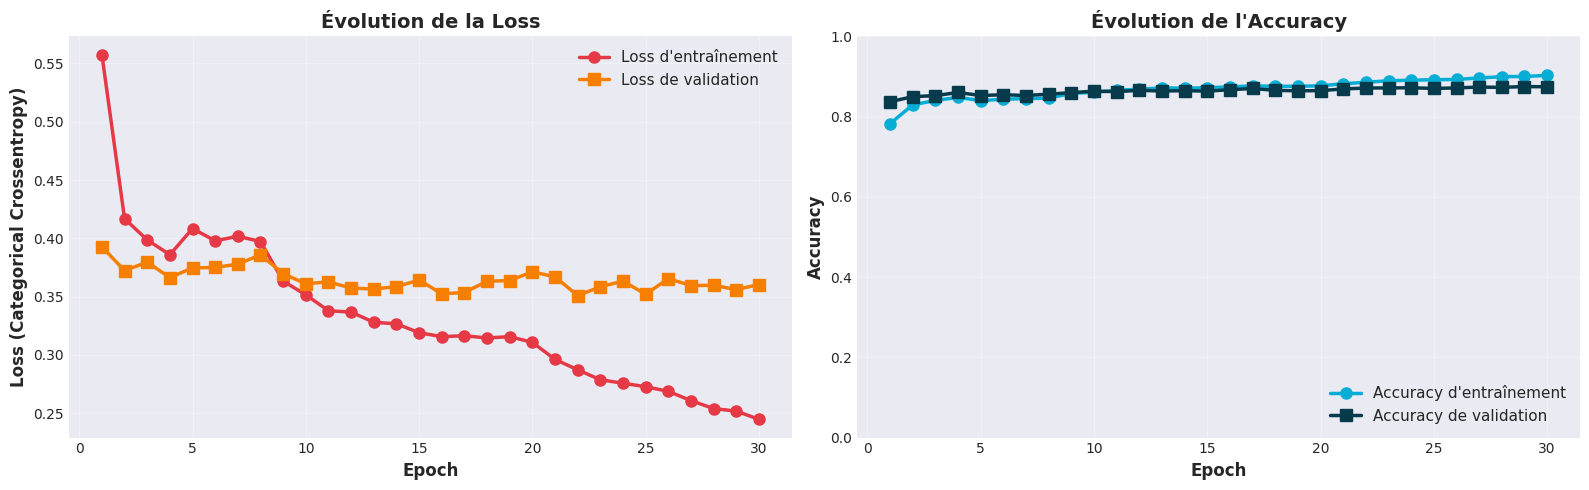


Epoch 30/30
Loss d'entraînement : 0.2448
Accuracy d'entraînement : 0.9027 (90.27%)

Loss de validation : 0.3604
Accuracy de validation : 0.8743 (87.43%)

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.
968/968 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.9027 - loss: 0.2448 - val_accuracy: 0.8743 - val_loss: 0.3604 - learning_rate: 0.0012
Restoring model weights from the end of the best epoch: 29.

✅ Entraînement LSTM terminé !


In [12]:
print("Starting learning...")

history = model.fit(
    pad_X_train, y_train,
    validation_data=(pad_X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, live_plot, reduce_on_plateau],
)

print("\n✅ Entraînement LSTM terminé !")

In [13]:
# Évaluation
test_loss, test_acc = model.evaluate(pad_X_test, y_test, verbose=0)
print("\n📊 PERFORMANCES LSTM")
print("=" * 60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")



📊 PERFORMANCES LSTM
Test Loss: 0.3697
Test Accuracy: 0.8720 (87.20%)


In [14]:
phrases = [
    "I don't feel like getting up, everything seems so dull",
    "Something's gonna happen here, something bad and I cannot do anything to prevent it",
    "Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?",
    "I got up, went to work, it was a wonderful day",
    "I would like to go to sleep and never wake up anymore", 
    "Everything is going so fast, my head is spinning, my heart is racing, I need a break"
]

for phrase in phrases:
    clean_phrase = clean_text(phrase)
    tokenized_phrase = tokenizer.texts_to_sequences([clean_phrase])
    padded_phrase = pad_sequences(tokenized_phrase, maxlen=MAX_LEN, padding='post')
    pred = model.predict(padded_phrase)
    print(phrase)
    print("It is", y_labels[np.argmax(pred, axis=1)[0]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
I don't feel like getting up, everything seems so dull
It is normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Something's gonna happen here, something bad and I cannot do anything to prevent it
It is suicidal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?
It is bipolar
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
I got up, went to work, it was a wonderful day
It is normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
I would like to go to sleep and never wake up anymore
It is suicidal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Everything is going so fast, my head is spinning, my heart is racing, I need a break
It is depression


In [15]:
y_pred = model.predict(pad_X_test, verbose=0)

y_test_idx = np.argmax(y_test, axis=1)
y_pred_idx = np.argmax(y_pred, axis=1)

print("\n📈 Classification Report:")
print(classification_report(y_test_idx, y_pred_idx, target_names=y_labels))


📈 Classification Report:
                      precision    recall  f1-score   support

             anxiety       0.94      0.94      0.94      3500
             bipolar       0.98      0.94      0.96      2712
          depression       0.72      0.71      0.72      3164
              normal       0.90      0.93      0.91      3183
personality disorder       0.98      0.95      0.97      2812
              stress       0.89      0.91      0.90      2941
            suicidal       0.68      0.69      0.68      2336

            accuracy                           0.87     20648
           macro avg       0.87      0.87      0.87     20648
        weighted avg       0.87      0.87      0.87     20648



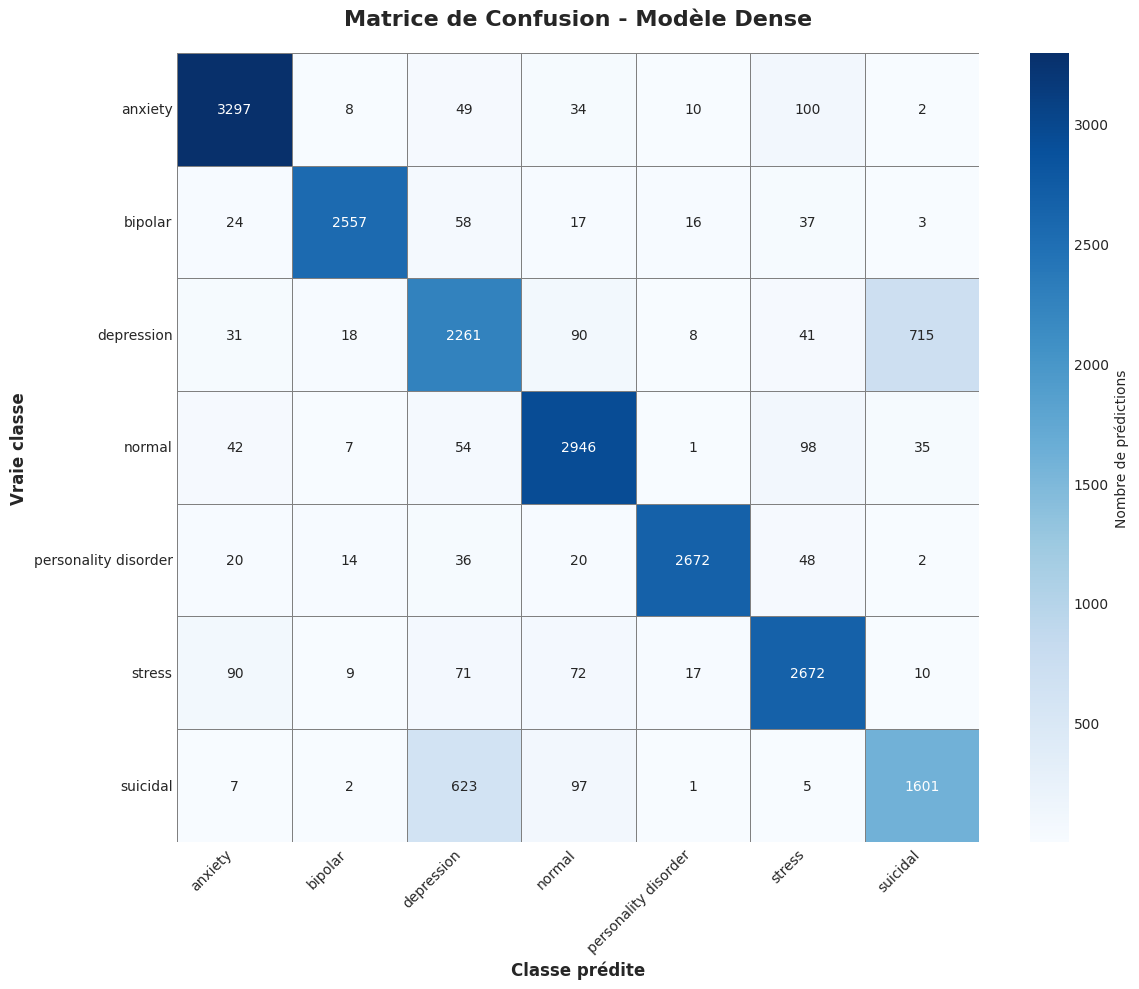

In [16]:
# Matrice de confusion
cm = confusion_matrix(y_test_idx, y_pred_idx)

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=y_labels, yticklabels=y_labels,
            cbar_kws={'label': 'Nombre de prédictions'},
            linewidths=0.5, linecolor='gray')
plt.title('Matrice de Confusion - Modèle Dense', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie classe', fontsize=12, fontweight='bold')
plt.xlabel('Classe prédite', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
model.save("model_lstm.keras")